In [18]:
#Prophet usa un modelo lineal para su pronóstico, en donde asimila que el valor y es directamente proporcional al tiempo
#En la vida real muchas cosas no crecen para siempre, ej: clientes, población, usuarios, ventas
#Ejemplo:
#Si un país tiene 50 millones de personas, una app no puede tener 200 millones de usuarios en ese país. Eso es la capacidad de carga
#Se dice que el pronostico se satura cuando el modelo se acerca al limite, por ende se vuelve cada vez más lento
#Prophet permite hacer pronsoticos usando un modelo logistico, agregandole una carga especificada, es decir el limte.

import pandas as pd
from prophet import Prophet
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')

#Valor maximo al que puede llegar la serie, es decir, normalmente se establece usando datos o experiencia sobre el tamaño del mercado
df['cap'] = 8.5

df.head

<bound method NDFrame.head of               ds          y  cap
0     2007-12-10   9.590761  8.5
1     2007-12-11   8.519590  8.5
2     2007-12-12   8.183677  8.5
3     2007-12-13   8.072467  8.5
4     2007-12-14   7.893572  8.5
...          ...        ...  ...
2900  2016-01-16   7.817223  8.5
2901  2016-01-17   9.273878  8.5
2902  2016-01-18  10.333775  8.5
2903  2016-01-19   9.125871  8.5
2904  2016-01-20   8.891374  8.5

[2905 rows x 3 columns]>

In [19]:
#Se especifica que se desea entrenar con el modelo logístico
m = Prophet(growth='logistic')
m.fit(df)

15:57:36 - cmdstanpy - INFO - Chain [1] start processing
15:57:36 - cmdstanpy - INFO - Chain [1] done processing


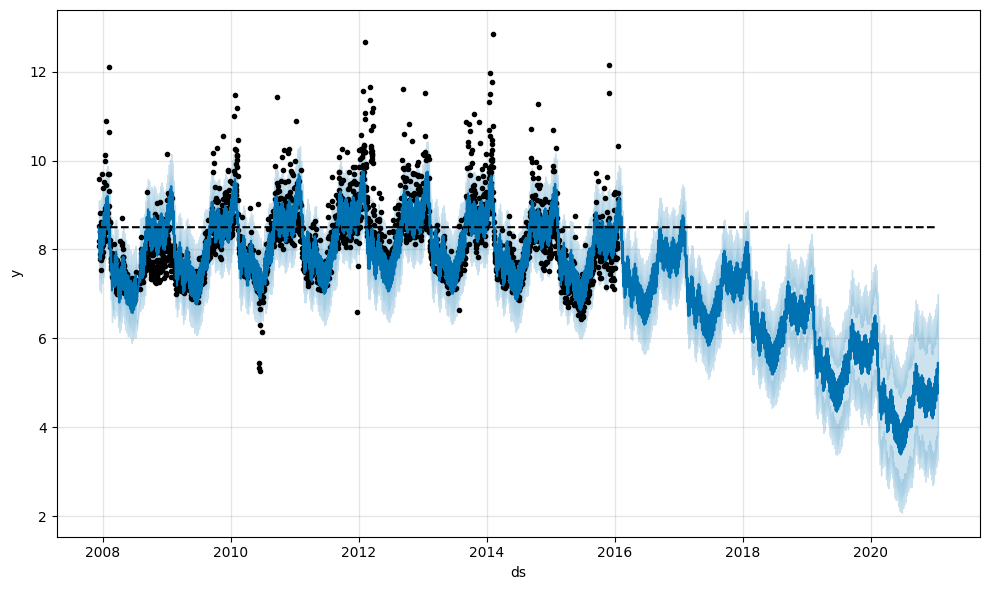

In [20]:
#Creamos marco de datos para predicciones futuras, tambien se debe especificar la capacidad en el futuro
future = m.make_future_dataframe(periods=1826)
future['cap'] = 8.5
fcst = m.predict(future)
fig = m.plot(fcst)

# Saturado mínimo
El crecimienot logístico también maneja un mínimo de saturación que se especifica en la columna floor de la msiam manera que el cap de la columna especifica mácimo:

16:17:00 - cmdstanpy - INFO - Chain [1] start processing
16:17:00 - cmdstanpy - INFO - Chain [1] done processing


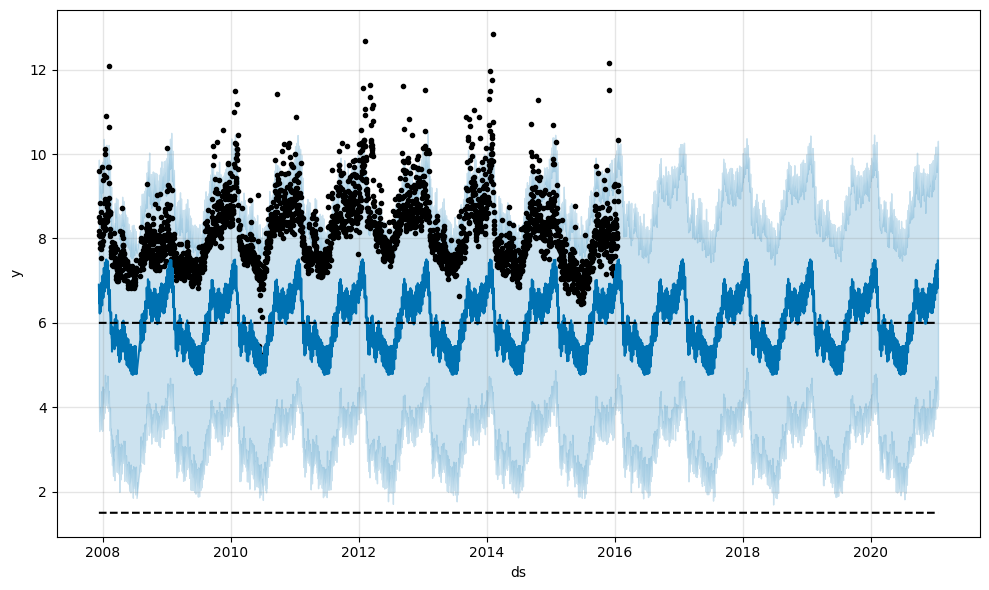

In [22]:
df['y'] = 10 - df['y']
df['cap'] = 6
df['floor'] = 1.5
future['cap'] = 6
future['floor'] = 1.5
m = Prophet(growth="logistic")
m.fit(df)
fcst = m.predict(future)
fig = m.plot(fcst)